# Backtest and Metrics

This notebook runs a **rolling-window backtest** on a single dataset: slide a context window through the time series, forecast the next `pred_len` steps with both **Migas-1.5** and **Chronos-2**, compare against ground truth, and compute standard metrics (MAE, MSE, MAPE, directional accuracy).

**Requirements:** Install the package (`uv sync`). For live summarization a vLLM server must be running; to skip it, use pre-computed summaries (see section at the end).

**Data:** Download prepared FNSPID assets:
```bash
uv run python scripts/download_fnspid.py --all
```

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import json, os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from migaseval import MigasPipeline
from migaseval.model.inference_utils import evaluate_chronos

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device=device)
print(f"Using device: {device}")

Loading Chronos-2 on device: cuda:0
Loading TimesFM 2.5...
Downloaded.
Compiling model...
TimesFM 2.5 loaded
Initialized univariate models: chronos, timesfm (prophet on-demand)
Using device: cuda


## Configure the backtest

In [2]:
csv_path = "../data/fnspid_prepared/fnspid_0.5_complement_csvs/adbe_with_text.csv"
df = pd.read_csv(csv_path)
print(f"Dataset: {os.path.basename(csv_path)}  —  {len(df)} rows")

seq_len = 384
pred_len = 16
stride = pred_len  # non-overlapping windows; set to 1 for fully rolling

n_windows = (len(df) - seq_len - pred_len) // stride + 1
print(f"seq_len={seq_len}, pred_len={pred_len}, stride={stride}  →  {n_windows} windows")

Dataset: adbe_with_text.csv  —  1000 rows
seq_len=384, pred_len=16, stride=16  →  38 windows


## Run rolling backtest

In [3]:
migas_forecasts = []
chronos_forecasts = []
ground_truths = []
last_context_values = []

for i in range(n_windows):
    start = i * stride
    end = start + seq_len

    df_ctx = df.iloc[start:end]
    gt = df["y_t"].values[end : end + pred_len]

    if len(gt) < pred_len:
        break

    # Migas-1.5 forecast
    migas_pred = pipeline.predict_from_dataframe(df_ctx, pred_len=pred_len)

    # Chronos-2 forecast (reuses the model already loaded by the pipeline)
    ctx_tensor = torch.tensor(
        df_ctx["y_t"].values.astype(np.float32)
    ).reshape(1, -1, 1)
    chronos_pred = evaluate_chronos(ctx_tensor, pred_len=pred_len, device=device)
    chronos_pred = chronos_pred[0, :, 0].detach().cpu().numpy()

    migas_forecasts.append(migas_pred)
    chronos_forecasts.append(chronos_pred)
    ground_truths.append(gt.astype(np.float32))
    last_context_values.append(float(df_ctx["y_t"].values[-1]))

    if (i + 1) % 10 == 0 or i == n_windows - 1:
        print(f"  Window {i + 1}/{n_windows}")

migas_forecasts = np.stack(migas_forecasts)        # (N, pred_len)
chronos_forecasts = np.stack(chronos_forecasts)  # (N, pred_len)
ground_truths = np.stack(ground_truths)          # (N, pred_len)
last_ctx = np.array(last_context_values)         # (N,)

print(f"\nBacktest complete: {len(migas_forecasts)} windows")

  Window 10/38
  Window 20/38
  Window 30/38
  Window 38/38

Backtest complete: 38 windows


## Forecast vs ground truth — sample windows

Plot a few individual windows so you can visually inspect forecast quality.

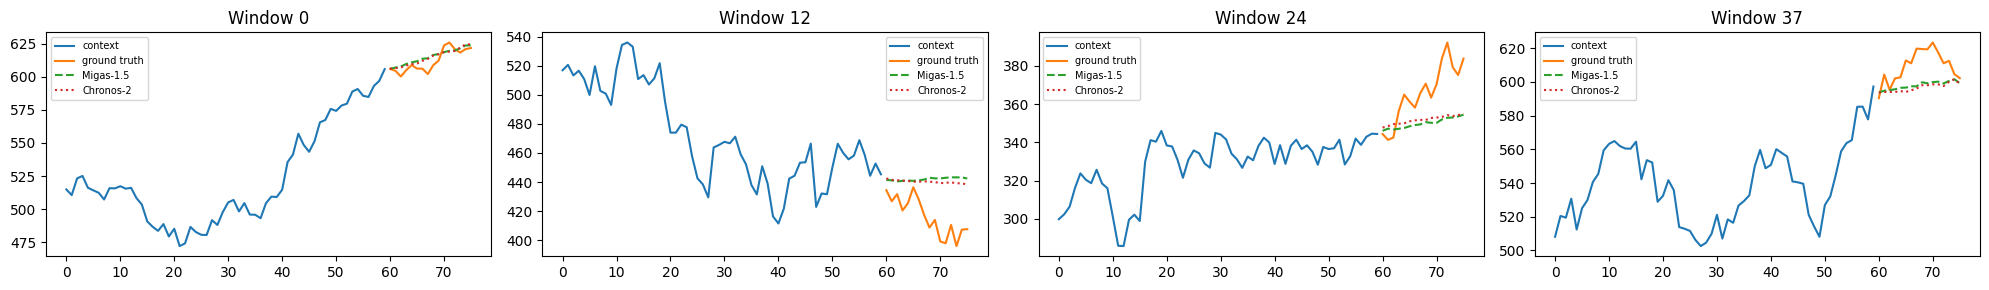

In [4]:
show_indices = np.linspace(0, len(migas_forecasts) - 1, min(4, len(migas_forecasts)), dtype=int)
tail = 60  # how many context steps to show before the forecast

fig, axes = plt.subplots(1, len(show_indices), figsize=(5 * len(show_indices), 3))
if len(show_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, show_indices):
    start = idx * stride
    ctx_vals = df["y_t"].values[start + seq_len - tail : start + seq_len]
    gt = ground_truths[idx]

    t = np.arange(len(ctx_vals) + pred_len)
    ax.plot(t[:len(ctx_vals)], ctx_vals, color="C0", label="context")
    ax.plot(t[len(ctx_vals):], gt, color="C1", label="ground truth")
    ax.plot(t[len(ctx_vals):], migas_forecasts[idx], color="C2", ls="--", label="Migas-1.5")
    ax.plot(t[len(ctx_vals):], chronos_forecasts[idx], color="C3", ls=":", label="Chronos-2")
    ax.set_title(f"Window {idx}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Compute metrics

In [5]:
def compute_backtest_metrics(preds, ground_truths, last_ctx):
    """Compute MAE, MSE, MAPE, and directional accuracy."""
    errors = preds - ground_truths
    mae_per_sample = np.mean(np.abs(errors), axis=1)
    mse_per_sample = np.mean(errors ** 2, axis=1)
    mape_per_sample = np.mean(
        np.abs(errors) / (np.abs(ground_truths) + 1e-8), axis=1
    ) * 100
    pred_dir = np.sign(preds[:, 0] - last_ctx)
    gt_dir = np.sign(ground_truths[:, 0] - last_ctx)
    valid = gt_dir != 0
    dir_acc = (pred_dir[valid] == gt_dir[valid]).mean() * 100 if valid.any() else float("nan")
    return {
        "MAE (mean)": np.mean(mae_per_sample),
        "MAE (median)": np.median(mae_per_sample),
        "MSE (mean)": np.mean(mse_per_sample),
        "MSE (median)": np.median(mse_per_sample),
        "MAPE % (mean)": np.mean(mape_per_sample),
        "MAPE % (median)": np.median(mape_per_sample),
        "Dir. acc % (step 1)": dir_acc,
    }

migas_metrics = compute_backtest_metrics(migas_forecasts, ground_truths, last_ctx)
chronos_metrics = compute_backtest_metrics(chronos_forecasts, ground_truths, last_ctx)

metrics_df = pd.DataFrame({"Migas-1.5": migas_metrics, "Chronos-2": chronos_metrics})
metrics_df.index.name = "metric"
print(metrics_df.to_string())

                      Migas-1.5   Chronos-2
metric                                     
MAE (mean)            22.174719   22.506559
MAE (median)          18.194534   19.466560
MSE (mean)           956.632996  977.098450
MSE (median)         553.789307  628.657654
MAPE % (mean)          4.904373    4.991366
MAPE % (median)        4.544223    4.635284
Dir. acc % (step 1)   37.837838   40.540541


## Offline backtest with pre-computed summaries

Pre-computed summaries from the FNSPID dataset use **stride=1** (one summary per rolling position). To match indices correctly, set `stride=1` above and pass the corresponding summary for each window. Below is a quick example loading the first few summaries.

In [7]:
dataset_name = os.path.splitext(os.path.basename(csv_path))[0]
summaries_dir = f"../data/fnspid_prepared/fnspid_0.5_complement/{dataset_name}"

offline_migas = []
offline_chronos = []
offline_gts = []
offline_last_ctx = []
n_offline = min(10, n_windows)  # demo with first 10 windows

for i in range(n_offline):
    start = i * stride
    end = start + seq_len
    gt = df["y_t"].values[end : end + pred_len].astype(np.float32)
    if len(gt) < pred_len:
        break

    summary_idx = start
    summary_path = os.path.join(summaries_dir, f"summary_{summary_idx}.json")
    if not os.path.exists(summary_path):
        print(f"  Window {i}: summary not found at {summary_path}, skipping")
        continue

    with open(summary_path) as f:
        summary = json.load(f)["summary"]

    df_ctx = df.iloc[start:end]
    context = df_ctx["y_t"].values.astype(np.float32).reshape(1, -1)

    migas_pred = pipeline.predict(context, pred_len=pred_len, summaries=[summary])
    ctx_tensor = torch.tensor(context).reshape(1, -1, 1)
    chronos_pred = evaluate_chronos(ctx_tensor, pred_len=pred_len, device=device)

    offline_migas.append(migas_pred[0, :, 0].detach().cpu().numpy())
    offline_chronos.append(chronos_pred[0, :, 0].detach().cpu().numpy())
    offline_gts.append(gt)
    offline_last_ctx.append(float(context[0, -1]))

if offline_migas:
    offline_migas = np.stack(offline_migas)
    offline_chronos = np.stack(offline_chronos)
    offline_gts = np.stack(offline_gts)
    offline_last_ctx = np.array(offline_last_ctx)
    m_migas15 = compute_backtest_metrics(offline_migas, offline_gts, offline_last_ctx)
    m_chron = compute_backtest_metrics(offline_chronos, offline_gts, offline_last_ctx)
    print(pd.DataFrame({"Migas-1.5 (offline)": m_migas15, "Chronos-2": m_chron}).to_string())
else:
    print("No summaries found — download them first: uv run python scripts/download_fnspid.py --summaries")

                     Migas-1.5 (offline)    Chronos-2
MAE (mean)                     29.034317    29.373814
MAE (median)                   29.780331    29.994377
MSE (mean)                   1661.948853  1690.496826
MSE (median)                 1361.596069  1344.317993
MAPE % (mean)                   5.077529     5.138530
MAPE % (median)                 4.582418     4.612469
Dir. acc % (step 1)            40.000000    40.000000
